In [25]:
import matplotlib as mpl
mpl.use('agg')
import sys; sys.path.insert(0,'/Users/ardasheva/Documents/NBI-postdoc/plottingTest')
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi, atan2, cos, sin
from massPy import archive 
from massPy.nematic import plot as nem_plot
from massPy.nematic import nematicPy as nem_tools
from massPy.utils import correlation as corr
import warnings
import lic
%matplotlib inline
warnings.filterwarnings('ignore')
from scipy import ndimage
from scipy.ndimage import zoom as ndz
from scipy.ndimage.interpolation import map_coordinates

In [17]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

# interface snapshots

In [3]:
def extractDirector(frame, LX, LY):
	QQxx = frame.QQxx
	QQyx = frame.QQyx

	Qxx_dat = QQxx.reshape(LX, LY)
	Qyx_dat = QQyx.reshape(LX, LY)

	S = np.vectorize(sqrt)(QQyx**2 + QQxx**2)
	nx = np.vectorize(sqrt)((1 + QQxx/S)/2)
	ny = np.sign(QQyx)*np.vectorize(sqrt)((1 - QQxx/S)/2)

	S  =  S.reshape((LX, LY))
	nx = nx.reshape((LX, LY))
	ny = ny.reshape((LX, LY))

	phi = frame.phi
	fric = frame.fric2save

	phi  =  phi.reshape((LX, LY))
	fric  =  fric.reshape((LX, LY))

	return S, nx, ny, phi, fric

def getLIC(phi, nx, ny, l):
	zf = 4
	nxz = ndz(nx, zf)
	nyz = ndz(ny, zf)

	lic_result = lic.lic(nxz, nyz, length=l, contrast=True)

	lic_masked = lic_result
	phi = np.repeat(phi,zf,axis=1)
	phi = np.repeat(phi,zf,axis=0)

	for i in range(np.size(lic_result,0)):
		for j in range(np.size(lic_result,1)):#
			#if phi[i,j] < 0.5: #change to 0.5 for interface
			#	lic_masked[i,j] = 0
			lic_masked[i,j] = lic_masked[i,j]*phi[i,j]

	return lic_masked

def scaleStresses(A, Nsc):
    new_dims = []
    for original_length, new_length in zip(A.shape, (Nsc,Nsc)):
        new_dims.append(np.linspace(0, original_length-1, new_length))

    coords = np.meshgrid(*new_dims, indexing='ij')
    B = map_coordinates(A, coords)
    return B

In [31]:
ar1 = archive.loadarchive('/Users/ardasheva/nbilustre/FrictionProject23/lyotropic/newmass/interface/case1.dat/')

frame = ar1[200]

generate lics: 100%|██████████| 20/20 [00:01<00:00, 15.91it/s]


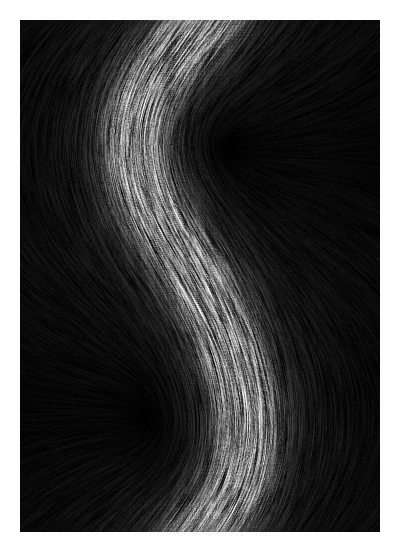

In [32]:
LX = frame.LX
LY = frame.LY

S, nx, ny, phi, fric = extractDirector(frame, LX, LY)
lic_result = getLIC(S, nx, ny, 40)
(LX, LY) = S.shape

fig=plt.figure(figsize=(2.66,2.86), dpi=200)
ax1 = fig.add_subplot(111)
ax1.imshow(lic_result, cmap='gray', origin='lower')
ax1.axis('off')
#ax1.set_box_aspect(1)
ax1.set_xlim([82,442])
#ax1.set_ylim([112,412])
plt.tight_layout()

plt.savefig('./figs/fig3/1a-case1.pdf')

# interface corrs

In [41]:
finter = np.load('../DATA/data-theory/newmass-interface/case4-Q.npy')
cinter = np.zeros((len(finter), 63))
for k in range(len(finter)):
    cinter[k,:] = finter[k][:]

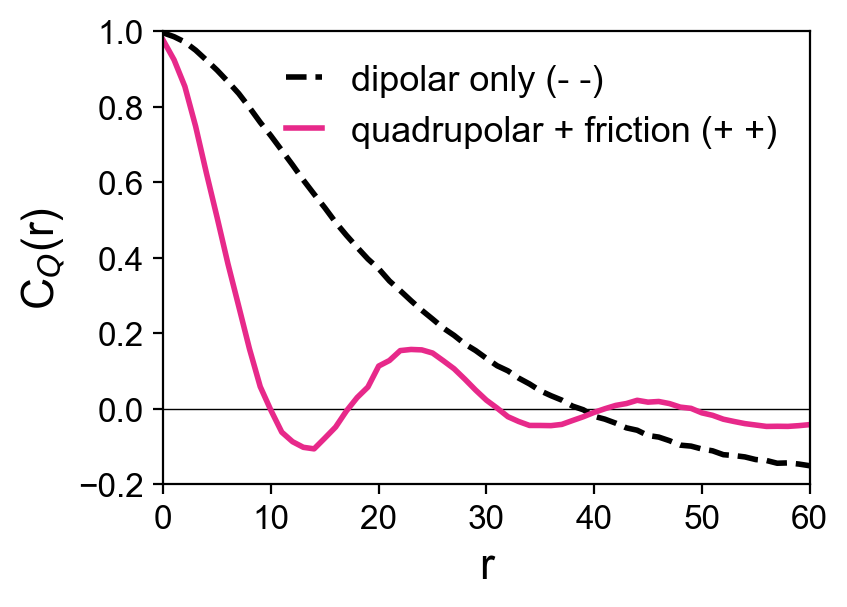

In [70]:
tBefore = np.mean(cinter[180:190],axis=0)
tBetween = np.mean(cinter[190:254],axis=0)
tQuadro = np.mean(cinter[255:275],axis=0)


f=plt.figure(figsize=(4.4,3.2), dpi=200)
ax1 = plt.subplot(111)
ax1.axhline(y=0,color='k', lw=0.5)

ax1.plot(tBefore, 'k--', lw=2,label='dipolar only (- -) ')
ax1.plot(tQuadro, color='#e7298a', lw=2,label='quadrupolar + friction (+ +)')

ax1.set_ylabel('C$_Q$(r)', fontsize=16)
ax1.set_xlabel('r', fontsize = 16)
ax1.set_ylim([-0.2,1])
ax1.set_xlim([0,60])

plt.legend(fontsize=13, frameon=False, handlelength=1)
#for axis in ['top','bottom','left','right']:
#    ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
plt.savefig('./figs/fig3/1b.pdf')

# exp dipolar activity

In [3]:
def corrcals(Nt, XX):
    Corrs = [[]]*Nt
    Clen = []

    for i in range(1,Nt):
        if len(str(i)) == 3:
            frn = '0'+str(i)
        elif len(str(i)) == 2:
            frn = '00'+str(i)
        elif len(str(i)) == 1:
            frn = '000'+str(i)

        S = np.genfromtxt('../DATA/data-experiments/fixed/'+XX+'/S-'+frn+'.csv', delimiter=',')
        THETA = np.genfromtxt('../DATA/data-experiments/fixed/'+XX+'/Theta-'+frn+'.csv', delimiter=',')

        THETAc=THETA
        nx = np.cos(THETAc)
        ny = np.sin(THETAc)

        C,r = corr.rdf2d2(nx[20:500,20:500],ny[20:500,20:500])

        for j in range(len(C)):
            if C[j] <= 1.0-1.0/2.71828:# or check location of minima

                cl = r[j]
                break

        Corrs[i-1] = C
        Clen.append(cl)
    return Corrs, Clen

In [4]:
CorrsHH, ClenHH = corrcals(599, 'HH')

In [5]:
CorrsLH, ClenLH = corrcals(699, 'LH')

In [6]:
dataND = np.genfromtxt('../DATA/data-experiments/domainN/HH-NumberOfDomains.dat', delimiter=' ')
dataND = np.genfromtxt('../DATA/data-experiments/domainN/HH-NumberOfDomains.dat', delimiter=' ')

dataNDLH = np.genfromtxt('../DATA/data-experiments/domainN/LH-NumberOfDomains.dat', delimiter=' ')
dataNDLH = np.genfromtxt('../DATA/data-experiments/domainN/LH-NumberOfDomains.dat', delimiter=' ')

timeHH = dataND[:,0]
valsHH = dataND[:,1]

timeLH = dataNDLH[:,0]
valsLH = dataNDLH[:,1]

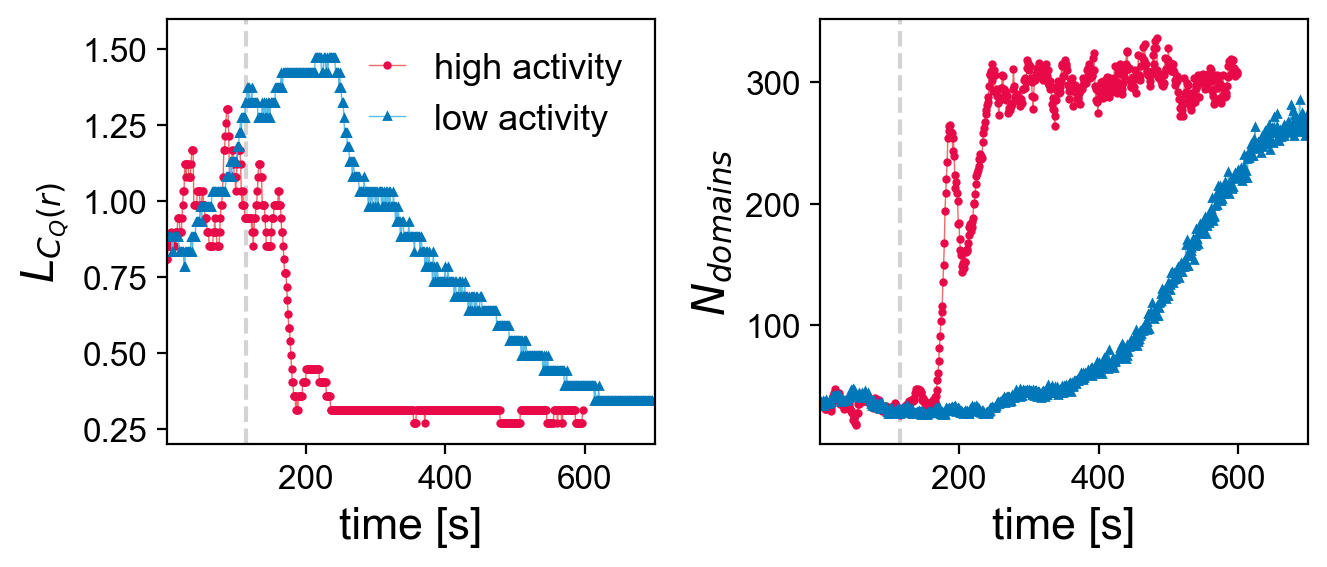

In [9]:
#normalisation
norm_cHH = np.asarray(np.mean(ClenHH[0:119]))
norm_cLH = np.asarray(np.mean(ClenLH[0:119]))

normNDHH = np.asarray(np.mean(valsHH[0:119]))
normNDLH = np.asarray(np.mean(valsLH[0:119]))


#plotting

f, ax=plt.subplots(1,2, figsize=(6.8,3),dpi=200)

ax[0].axvline(x=115,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[0].plot(ClenHH/norm_cHH, color='#f06969',marker='.', markerfacecolor='#e80948',markeredgecolor='#e80948',markersize=4, lw=0.5)
ax[0].plot(ClenLH/norm_cLH, color='#5abde8',marker='^', markerfacecolor='#0077b8',markeredgecolor='#0077b8',markersize=2, lw=0.5)
ax[0].set_xlim([1,700])
ax[0].set_ylim([0.2,1.6])
ax[0].set_xlabel('time [s]', fontsize=16)
ax[0].set_ylabel('$L_{C_{Q}(r)}$', fontsize=16)
ax[0].legend(['high activity', 'low activity'], fontsize=13, frameon=False, handlelength=1)


ax[1].axvline(x=115,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[1].plot(valsHH, color='#f06969',marker='.', markerfacecolor='#e80948',markeredgecolor='#e80948',markersize=4, lw=0.5)
ax[1].plot(valsLH, color='#5abde8',marker='^', markerfacecolor='#0077b8',markeredgecolor='#0077b8',markersize=2, lw=0.5)
ax[1].set_xlim([1,700])
#ax[1].set_ylim([0,10])
ax[1].set_xlabel('time [s]', fontsize=16)
ax[1].set_ylabel('$N_{domains}$', fontsize=16)



    
plt.tight_layout()

plt.savefig('./figs/fig3/1c.pdf')



# sims dipolar activity

In [10]:
def getClenDIR(N,t, zeta, fric,q, frate,r):
    if N!=1:
        Cout = np.zeros((N,63))
        Clen = []
        for n in range(N):
            f = np.load('../DATA/data-theory/frate/Analysis/z'+zeta+'fric'+fric+'q'+q+'LL0.2frate'+frate+'GQ0.1r'+str(n+1)+'.dat.npy')
            C = f[t][:]
            r = np.linspace(0,len(C),len(C))
            for j in range(len(C)):
                if C[j] <= 1.0-1.0/2.71828:
                    cl = r[j]
                    break
    else:
        Cout = np.zeros((1,63))
        Clen = []
        n=r
        f = np.load('../DATA/data-theory/frate/Analysis/z'+zeta+'fric'+fric+'q'+q+'LL0.2frate'+frate+'GQ0.1r'+str(n)+'.dat.npy')
        C = f[t][:]
        r = np.linspace(0,len(C),len(C))
        for j in range(len(C)):
            if C[j] <= 1.0-1.0/2.71828:
                cl = r[j]
                break
        
        Cout[0,:] = C
        Clen.append(cl)
        
    return Cout, Clen

def getgetDIR(Ntt, N, zeta, fric, q, frate,r):
    corrsM = [[]]*Ntt; corrsE = [[]]*Ntt;
    clenM = []; clenE = [];
    for t in range(Ntt):
        Cout, Clen = getClenDIR(N,t, zeta, fric, q, frate,r)
        
        corrsM[t]= np.mean(Cout, 0); corrsE[t]= np.std(Cout,0)
        clenM.append(np.mean(Clen, 0)); clenE.append(np.std(Clen,0))
        
    return corrsM, corrsE, clenM, clenE

In [11]:
N = 1;Ntt = 620
zetav = '0.2'; fricv = '10'

corrsMa, corrsEa, clenMa, clenEa = getgetDIR(Ntt, N, '0.2', fricv,'0.4', '10000',2)
corrsMb, corrsEb, clenMb, clenEb = getgetDIR(Ntt, N, '0.02', fricv,'0.4', '10000',2)

r = np.linspace(0,len(corrsMa[0]),len(corrsMa[0]))

ninfo=25
t = np.linspace(19500,35000,len(clenEa))

In [12]:
thr='0.9'

outHH = np.load('../DATA/data-theory/frate/cluster/checkz0.2fric10q0.4LL0.2frate10000GQ0.1r'+str(2)+'-thr' +str(thr)+'_domno.npy')
outLH = np.load('../DATA/data-theory/frate/cluster/checkz0.02fric10q0.4LL0.2frate10000GQ0.1r'+str(2)+'-thr' +str(thr)+'_domno.npy')

print(len(outLH))


tn = np.linspace(19500,35000-25,len(outLH))


620


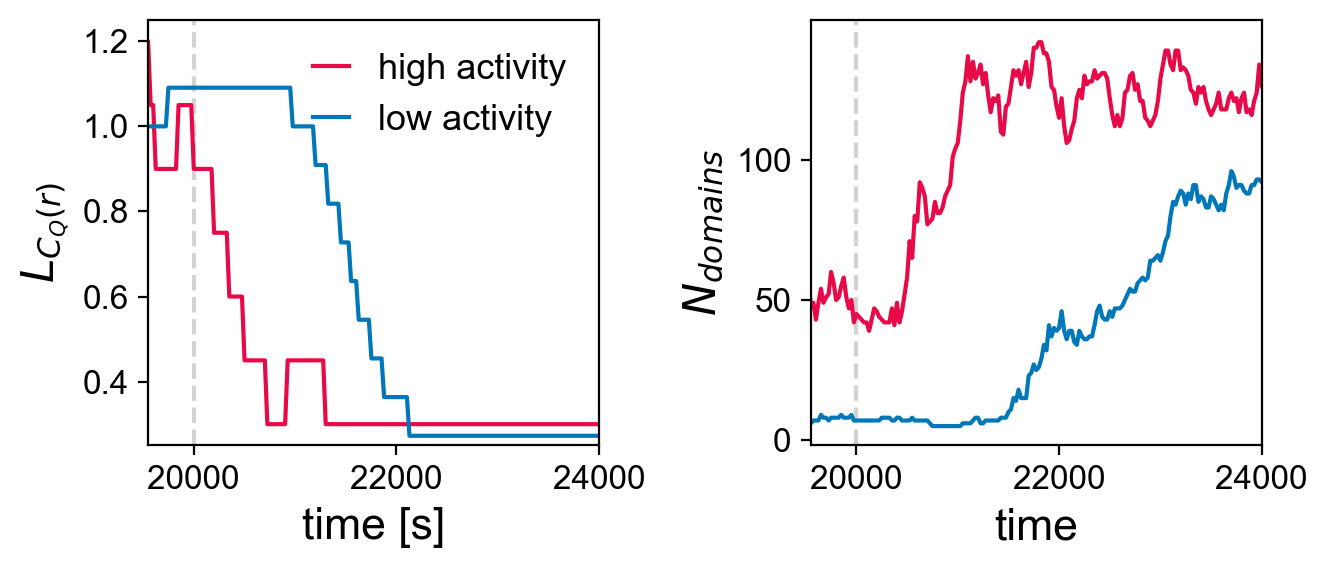

In [15]:
a_c = np.asarray(np.mean(clenMa[1:10]))
b_c = np.asarray(np.mean(clenMb[1:10]))
c_c = np.asarray(np.mean(outHH[1:10]))
d_c = np.asarray(np.mean(outLH[1:10]))

f, ax=plt.subplots(1,2, figsize=(6.8,3),dpi=200)

ax[0].axvline(x=20000,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[0].plot(t,clenMa/a_c, color='#e80948',lw=1.5)
ax[0].plot(t,clenMb/b_c, color='#0077b8', lw=1.5)
ax[0].set_xlim([19550,24000])
ax[0].set_ylim([0.25,1.25])
ax[0].set_xlabel('time [s]', fontsize=16)
ax[0].set_ylabel('$L_{C_{Q}(r)}$', fontsize=16)
ax[0].legend(['high activity', 'low activity'], fontsize=13, frameon=False, handlelength=1)


ax[1].axvline(x=20000,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[1].plot(tn,outHH, color='#e80948', lw=1.5)
ax[1].plot(tn,outLH, color='#0077b8',lw=1.5)
ax[1].set_xlim([19550,24000])
#ax[1].set_ylim([0,10])
ax[1].set_xlabel('time', fontsize=16)
ax[1].set_ylabel('$N_{domains}$', fontsize=16)


plt.tight_layout()
plt.savefig('./figs/fig3/1d'+thr+'.pdf')

# sims extra

In [202]:
def givemeclen(z):
    corr1 = np.load('../DATA/data-theory/frate/clusteradditional/z'+z+'fric10q0.4LL0.2frate10000GQ0.1r2.dat-Q.npy')

    Nc = len(corr1)
    out1 = []
    for l in range(Nc-1):
        C = corr1[l][:]
        r = np.linspace(0,len(C),len(C))
        for j in range(len(C)):
            if C[j] <= 1.0-1.0/2.71828:
                cl = r[j]
                break

        out1.append(cl)
    return out1

clenH1 = givemeclen('0.15')
clenH2 = givemeclen('0.1')
clenH3 = givemeclen('0.15')
corrsMa, corrsEa, clenMa, clenEa = getgetDIR(Ntt, N, '0.2', fricv,'0.4', '10000',2)


a_c = np.asarray(np.mean(clenMa[1:10]))
b_c = np.asarray(np.mean(clenH1[1:10]))
c_c = np.asarray(np.mean(clenH2[1:10]))
d_c = np.asarray(np.mean(clenH3[1:10]))



In [203]:
thr='0.9'

outHH = np.load('../DATA/data-theory/frate/cluster/z0.2fric10q0.4LL0.2frate10000GQ0.1r'+str(2)+'-thr' +str(thr)+'_domno.npy')

out1v = np.load('../DATA/data-theory/frate/clusteradditional/z0.05fric10q0.4LL0.2frate10000GQ0.1r'+str(2)+'.dat-thr' +str(thr)+'_domnoPHI.npy')


a_c1 = np.asarray(np.mean(outHH[1:10]))
b_c1 = np.asarray(np.mean(out1v[1:10]))
tn = np.linspace(19500,35000-25,len(outHH))

NameError: name 'a_c' is not defined

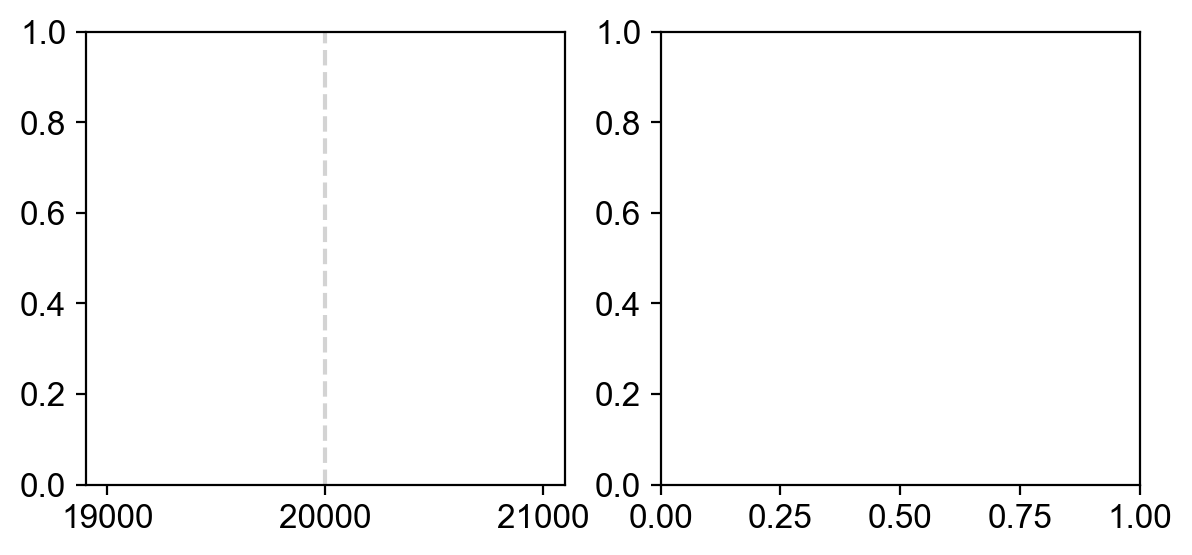

In [13]:
f, ax=plt.subplots(1,2, figsize=(6.8,3),dpi=200)

ax[0].axvline(x=20000,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[0].plot(t,clenMa/a_c, color='#e80948',lw=1.5)
#ax[0].plot(t,clenH1/b_c, color='#1f78b4', lw=1.5)
#ax[0].plot(t,clenH2/c_c, color='g', lw=1.5)
ax[0].plot(t,clenH3/d_c, color='#0077b8', lw=1.5)
ax[0].set_xlim([19550,23000])
ax[0].set_ylim([0.25,1.25])
ax[0].set_xlabel('time [s]', fontsize=16)
ax[0].set_ylabel('$L_{C_{Q}(r)}$', fontsize=16)
ax[0].legend(['z=0.2', 'z=0.05','0.1','0.05'], fontsize=13, frameon=False, handlelength=1)


ax[1].axvline(x=20000,color='lightgrey', lw=1.5, ls='--',label='_nolegend_')
ax[1].plot(tn,outHH, color='#e80948', lw=1.5)
#ax[1].plot(tn,outLH/d_c, color='#1f78b4',lw=1.5)
ax[1].plot(tn,out1v, color='#0077b8', lw=1.5)
ax[1].set_xlim([19550,23000])
#ax[1].set_ylim([0,10])
ax[1].set_xlabel('time', fontsize=16)
ax[1].set_ylabel('$N_{domains}$', fontsize=16)


plt.tight_layout()